# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [22]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [23]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx]
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [24]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

Loading data from: /Users/sara/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [25]:
print(images.shape)

(100000, 96, 96, 3)


In [26]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

# train_images = images[:8000]
# val_images = images[8000:9000]
# test_images = images[9000:]


In [27]:
train_generator = PatchGenerator(train_images, batch_size=64)
val_generator = PatchGenerator(val_images, batch_size=64)
test_generator = PatchGenerator(test_images, batch_size=64)

Let us inspect the dataset.

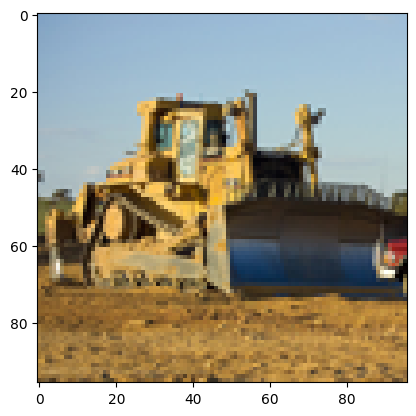

In [28]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [30]:
a,b = test_generator.__getitem__(1)

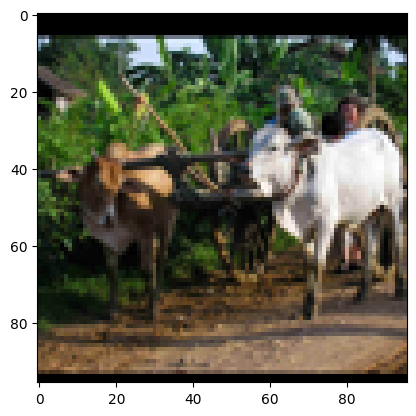

In [31]:
plt.imshow(b[4])

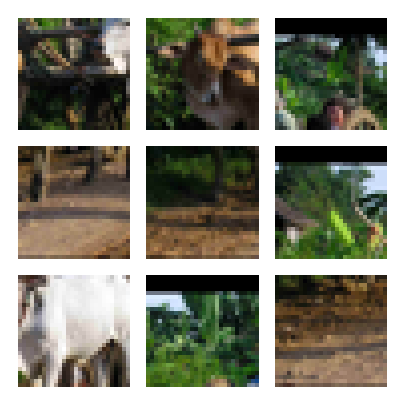

In [32]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [33]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [34]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.18245183, shape=(), dtype=float32)
std: tf.Tensor(0.000619524, shape=(), dtype=float32)


In [35]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers


# def build_patch_encoder():

#     inp = keras.Input((28,28,3))

#     x = layers.Conv2D(32,3,padding="same")(inp)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.Conv2D(32,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(64,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.Conv2D(64,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(128,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.GlobalAveragePooling2D()(x)

#     x = layers.Dense(256)(x)

#     return keras.Model(inp,x)

In [36]:
# class TransformerBlock(layers.Layer):

#     def __init__(self,
#                  dim=256,
#                  heads=8,
#                  ff_dim=512,
#                  dropout=0.1):

#         super().__init__()

#         self.att = layers.MultiHeadAttention(
#             num_heads=heads,
#             key_dim=dim//heads
#         )

#         self.ff = keras.Sequential([
#             layers.Dense(ff_dim,activation="gelu"),
#             layers.Dropout(dropout),
#             layers.Dense(dim)
#         ])

#         self.norm1 = layers.LayerNormalization()
#         self.norm2 = layers.LayerNormalization()

#     def call(self,x):

#         a = self.att(x,x)

#         x = self.norm1(x+a)

#         f = self.ff(x)

#         x = self.norm2(x+f)

#         return x

In [37]:
# def build_model():

#     inp = keras.Input((9,28,28,3))

#     encoder = build_patch_encoder()

#     tokens = layers.TimeDistributed(
#         encoder
#     )(inp)

#     tokens = TransformerBlock()(tokens)
#     tokens = TransformerBlock()(tokens)
#     tokens = TransformerBlock()(tokens)

#     position_logits = layers.Dense(9)(tokens)

#     position_probs = layers.Softmax(axis=-1)(position_logits)

#     grid = layers.Lambda(
#         lambda z: tf.matmul(
#             z[0],
#             z[1],
#             transpose_a=True
#         )
#     )([position_probs,tokens])

#     grid = layers.Reshape((3,3,256))(grid)


#     x = layers.Conv2D(256,3,padding="same",activation="relu")(grid)

#     x = layers.UpSampling2D()(x)  # 6×6
#     x = layers.Conv2D(256,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 12×12
#     x = layers.Conv2D(128,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 24×24
#     x = layers.Conv2D(128,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 48×48
#     x = layers.Conv2D(64,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 96×96
#     x = layers.Conv2D(32,3,padding="same",activation="relu")(x)

#     out = layers.Conv2D(3,1,activation="sigmoid")(x)

#     return keras.Model(inp,out)

In [38]:
# x, y = train_generator[0]
# print(x.shape, y.shape)

In [39]:
# model = build_model()

# model.compile(
#     optimizer=keras.optimizers.Adam(1e-3),
#     loss="mae"
# )

# model.summary()

In [40]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# import numpy as np

# # -------------------------------------------------------------
# # 1. KEEP OR IMPROVE PATCH ENCODER (as allowed)
# # -------------------------------------------------------------
# def build_patch_encoder():
#     inp = keras.Input((28, 28, 3))

#     x = layers.Conv2D(32, 3, padding="same")(inp)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.Conv2D(32, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(64, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.Conv2D(64, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(128, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(256)(x)
#     return keras.Model(inp, x, name="patch_encoder")

# # -------------------------------------------------------------
# # 2. STANDARD TRANSFORMER BLOCK
# # -------------------------------------------------------------
# class TransformerBlock(layers.Layer):
#     def __init__(self, dim=256, heads=8, ff_dim=512, dropout=0.1, **kwargs):
#         super().__init__(**kwargs)
#         self.att = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)
#         self.ff = keras.Sequential([
#             layers.Dense(ff_dim, activation="gelu"),
#             layers.Dropout(dropout),
#             layers.Dense(dim)
#         ])
#         self.norm1 = layers.LayerNormalization()
#         self.norm2 = layers.LayerNormalization()

#     def call(self, x):
#         a = self.att(x, x)
#         x = self.norm1(x + a)
#         f = self.ff(x)
#         x = self.norm2(x + f)
#         return x

# # -------------------------------------------------------------
# # 3. COMPLETE REWRITTEN MODEL (Under 6M Params)
# # -------------------------------------------------------------
# def build_model():
#     # Input shape: (Batch, 9 patches, 28, 28, 3)
#     inp = keras.Input((9, 28, 28, 3))
    
#     # Step 1: Encode Patches independently
#     encoder = build_patch_encoder()
#     tokens = layers.TimeDistributed(encoder)(inp) # Shape: (Batch, 9, 256)
    
#     # Step 2: Contextualize scrambled patches via self-attention
#     tokens = TransformerBlock(dim=256, heads=8, ff_dim=512)(tokens)
#     tokens = TransformerBlock(dim=256, heads=8, ff_dim=512)(tokens)

#     # Step 3: Create 9 Target Position Grid Queries 
#     # This acts as a template for the target 3x3 layout (Top-Left to Bottom-Right)
#     grid_queries = layers.Embedding(input_dim=9, output_dim=256)(tf.range(9))
    
#     # FIX: Pass both tensors to Lambda so it can dynamically tile across the batch size
#     grid_queries = layers.Lambda(
#         lambda x: tf.tile(x[0][None, :, :], [tf.shape(x[1])[0], 1, 1])
#     )([grid_queries, tokens])

#     # Step 4: Cross-Attention
#     # Queries = Target positions (ordered 0-8)
#     # Keys/Values = Encoded scrambled patch tokens
#     cross_attention = layers.MultiHeadAttention(num_heads=8, key_dim=256 // 8)
#     grid_mapped = cross_attention(query=grid_queries, value=tokens, key=tokens)
#     grid_mapped = layers.LayerNormalization()(grid_mapped + grid_queries)

#     # Step 5: Convert the ordered tokens into a 3x3 Grid
#     grid = layers.Reshape((3, 3, 256))(grid_mapped)

#     # Step 6: Powerful Fully-Convolutional Image Decoder Head
#     x = layers.Conv2D(256, 3, padding="same")(grid)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     # 3x3 -> 6x6
#     x = layers.UpSampling2D(size=(2, 2))(x)  
#     x = layers.Conv2D(128, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     # 6x6 -> 12x12
#     x = layers.UpSampling2D(size=(2, 2))(x)  
#     x = layers.Conv2D(128, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     # 12x12 -> 24x24
#     x = layers.UpSampling2D(size=(2, 2))(x)  
#     x = layers.Conv2D(64, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     # 24x24 -> 48x48
#     x = layers.UpSampling2D(size=(2, 2))(x)  
#     x = layers.Conv2D(32, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     # 48x48 -> 96x96
#     x = layers.UpSampling2D(size=(2, 2))(x)  
#     x = layers.Conv2D(32, 3, padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     # Final Output Layer (Produces 96x96x3 image normalized between 0.0 and 1.0)
#     out = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

#     return keras.Model(inp, out)

# # Instantiate the model
# model = build_model()

# # Compile using MAE as required by your project instructions
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     loss="mae"
# )

# # Explicitly print parameter count to prove it's under 6 Million
# model.summary()


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np



import matplotlib.pyplot as plt
import numpy as np

def plot_jigsaw_evaluation(model, generator, sample_idx=0):
    """
    Grabs a batch from the generator, gets the model prediction,
    and plots the Scrambled Input vs. Model Reconstruction vs. Ground Truth.
    """
    # 1. Fetch a batch of data
    X_batch, Y_batch = generator[0]
    
    # Extract a single sample from the batch
    scrambled_patches = X_batch[sample_idx]  # Shape: (9, 28, 28, 3)
    ground_truth_img = Y_batch[sample_idx]   # Shape: (96, 96, 3)
    
    # 2. Get the model's prediction
    # Expand dims to simulate a batch of size 1 for the model
    prediction = model.predict(np.expand_dims(scrambled_patches, axis=0), verbose=0)
    reconstructed_img = prediction[0]        # Shape: (96, 96, 3)
    
    # 3. Create a canvas for the scrambled input patches (3x3 grid layout)
    # We replicate how the generator creates a 96x96 canvas but keep them in slot order
    scrambled_canvas = np.ones((96, 96, 3), dtype=np.float32)
    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    for i in range(9):
        row = i // 3
        col = i % 3
        
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim
        
        scrambled_canvas[y_start:y_end, x_start:x_end] = scrambled_patches[i]

    # 4. Plotting the three images side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot Scrambled Input
    axes[0].imshow(scrambled_canvas)
    axes[0].set_title("1. Scrambled Input (Model Input)")
    axes[0].axis('off')
    
    # Plot Model Prediction
    axes[1].imshow(reconstructed_img)
    axes[1].set_title("2. Model Reconstruction")
    axes[1].axis('off')
    
    # Plot Target Ground Truth
    axes[2].imshow(ground_truth_img)
    axes[2].set_title("3. Ground Truth Target")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# After you have trained or loaded your model, simply call:
# plot_jigsaw_evaluation(model, test_generator, sample_idx=0)



# -------------------------------------------------------------
# 1. IMPROVED PATCH ENCODER (Deeper, Slimmer, Better Features)
# -------------------------------------------------------------
def build_patch_encoder():
    inp = keras.Input((28, 28, 3))

    # block 1: 28x28 -> 14x14
    x = layers.Conv2D(32, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # block 2: 14x14 -> 7x7
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # block 3: 7x7 -> 4x4
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="gelu")(x)
    return keras.Model(inp, x, name="patch_encoder")

# -------------------------------------------------------------
# 2. STANDARD TRANSFORMER BLOCK
# -------------------------------------------------------------
class TransformerBlock(layers.Layer):
    def __init__(self, dim=256, heads=8, ff_dim=512, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)
        self.ff = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, x):
        a = self.att(x, x)
        x = self.norm1(x + a)
        f = self.ff(x)
        x = self.norm2(x + f)
        return x

# -------------------------------------------------------------
# 3. UPGRADED HIGH-RESOLUTION MODEL (Under 6M Params)
# -------------------------------------------------------------
def build_model():
    # Input shape: (Batch, 9 patches, 28, 28, 3)
    inp = keras.Input((9, 28, 28, 3))
    
    # Step 1: Encode Patches independently
    encoder = build_patch_encoder()
    tokens = layers.TimeDistributed(encoder)(inp) # Shape: (Batch, 9, 256)
    
    # Step 2: Contextualize scrambled patches via self-attention
    tokens = TransformerBlock(dim=256, heads=8, ff_dim=512)(tokens)
    tokens = TransformerBlock(dim=256, heads=8, ff_dim=512)(tokens)

    # Step 3: Create 9 Target Position Grid Queries
    grid_queries = layers.Embedding(input_dim=9, output_dim=256)(tf.range(9))
    grid_queries = layers.Lambda(
        lambda x: tf.tile(x[0][None, :, :], [tf.shape(x[1])[0], 1, 1])
    )([grid_queries, tokens])

    # Step 4: Cross-Attention to Map Patches to Positions
    cross_attention = layers.MultiHeadAttention(num_heads=8, key_dim=256 // 8)
    grid_mapped = cross_attention(query=grid_queries, value=tokens, key=tokens)
    grid_mapped = layers.LayerNormalization()(grid_mapped + grid_queries)

    # Step 5: Convert the ordered tokens into a 3x3 Grid
    grid = layers.Reshape((3, 3, 256))(grid_mapped)

    # -------------------------------------------------------------
    # Step 6: MINI U-NET DECODER HEAD (Prevents Blur & Keeps Sharpness)
    # -------------------------------------------------------------
    # Feature Extraction / Down-sampling paths via Skip-like structures
    # --- ENHANCED DECODER ---
    # 3x3 -> 6x6
    x = layers.UpSampling2D(size=(2, 2))(grid)  
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x1 = layers.ReLU()(x) # Keep for skip

    # 6x6 -> 12x12
    x = layers.UpSampling2D(size=(2, 2))(x1)  
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x2 = layers.ReLU()(x) # Keep for skip

    # 12x12 -> 24x24
    x = layers.UpSampling2D(size=(2, 2))(x2)  
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x3 = layers.ReLU()(x) # Keep for skip

    # 24x24 -> 48x48
    x = layers.UpSampling2D(size=(2, 2))(x3)  
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x4 = layers.ReLU()(x) 

    # 48x48 -> 96x96
    x = layers.UpSampling2D(size=(2, 2))(x4)  
    
    # Project and concatenate intermediate layers cleanly
    x3_up = layers.UpSampling2D(size=(4, 4))(x3) # 24x24 -> 96x96
    x2_up = layers.UpSampling2D(size=(8, 8))(x2) # 12x12 -> 96x96
    
    x = layers.Concatenate()([x, x3_up, x2_up])
    
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    out = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(inp, out)

# Instantiate the model
model = build_model()

# Compile using MAE as required
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4), # Slightly lower LR for transformer stability
    loss="mae"
)

# Explicitly print parameter count to prove it's under 6 Million
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 256)    │    173,728 │ input_layer_4[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 9, 256)    │    527,104 │ time_distributed… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 9, 256)    │    527,104 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 9, 256)    │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 256)    │    263,168 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ lambda_1[0][0],   │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 256)    │          0 │ multi_head_atten… │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 256)    │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 3, 3, 256) │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 6, 6, 256) │          0 │ reshape_1[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 6, 6, 128) │    295,040 │ up_sampling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 6, 128) │        512 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 12, 12,    │          0 │ re_lu_15[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 12, 12,    │    147,584 │ up_sampling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        512 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 12, 12,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 24, 24,    │          0 │ re_lu_16[0][0]  

 Total params: 2,121,251 (8.09 MB)

 Trainable params: 2,119,779 (8.09 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [41]:
x, y = train_generator[0]
print(x.shape, y.shape)

(64, 9, 28, 28, 3) (64, 96, 96, 3)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    # Stops training if validation loss stops improving for 4 epochs
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    
    # Saves your model file automatically when it achieves a new best val_loss
    ModelCheckpoint('best_jigsaw_model.keras', monitor='val_loss', save_best_only=True),
    
    # Drops learning rate if progress stalls to fine-tune the weights
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=2
)

Epoch 1/2
 192/1250 ━━━━━━━━━━━━━━━━━━━━ 16:55 960ms/step - loss: 0.1894

In [ ]:
import numpy as np
import tensorflow as tf

mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_values = []

for i in range(len(test_generator)):
    x, y = test_generator[i]
    pred = model.predict(x, verbose=0)

    mae_metric.update_state(y, pred)
    mae_values.append(tf.reduce_mean(tf.abs(y - pred)))

print("FINAL TEST PERFORMANCE:")
print("MAE:", mae_metric.result().numpy())
print("STD:", tf.math.reduce_std(mae_values).numpy())
print("-" * 50)

# 3. CALL THE PLOT CODE HERE TO VISUALIZE RESULTS
print("Generating visual evaluation plot...")
# This will pick the very first image (index 0) from your test generator
plot_jigsaw_evaluation(model, test_generator, sample_idx=0)



In [ ]:
model.save("jigsaw_model.keras")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_three_way_comparison(model, generator, batch_idx=1, sample_idx=4):
    """
    Plots the Scrambled Grid, the Model's Output, and the Original Target Image
    side-by-side for a clean visual presentation.
    """
    # 1. Fetch the exact batch and sample you requested
    X_batch, Y_batch = generator[batch_idx]
    scrambled_patches = X_batch[sample_idx]  # Shape: (9, 28, 28, 3)
    ground_truth_img = Y_batch[sample_idx]   # Shape: (96, 96, 3)
    
    # 2. Get the model prediction
    # (We add an extra dimension because the model expects a batch input)
    prediction = model.predict(np.expand_dims(scrambled_patches, axis=0), verbose=0)
    reconstructed_img = prediction[0]        # Shape: (96, 96, 3)
    
    # 3. Create a temporary canvas for the scrambled patches so it matches the 96x96 layout
    scrambled_canvas = np.ones((96, 96, 3), dtype=np.float32)
    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    for i in range(9):
        row = i // 3
        col = i % 3
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim
        scrambled_canvas[y_start:y_end, x_start:x_end] = scrambled_patches[i]

    # 4. Set up the 3-column plot layout
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Column 1: Input Scrambled Puzzle
    axes[0].imshow(scrambled_canvas)
    axes[0].set_title("1. Scrambled Input", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Column 2: What your model created
    axes[1].imshow(reconstructed_img)
    axes[1].set_title("2. Model Output", fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Column 3: The real target image
    axes[2].imshow(ground_truth_img)
    axes[2].set_title("3. Ground Truth Target", fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- HOW TO DEPLOY IT ---
# Simply run this line at the bottom of your script:
show_three_way_comparison(model, test_generator, batch_idx=1, sample_idx=4)

In [ ]:
def plot_learning_curves(history):
    """Plots the training and validation MAE history."""
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train MAE Loss', color='royalblue', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val MAE Loss', color='darkorange', linewidth=2)
    
    plt.title('Model Training Progress (Mean Absolute Error)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (MAE)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Run it using the training history variable:
plot_learning_curves(history)

# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.



